# Day 16 — PCM + Refrigerator Integration Model
**Mahesha Gonal — Refrigeration Simulation Portfolio**

Compares bottle-cooling response inside a refrigerator cabin with vs without a PCM buffer pack — recreating the mechanism behind the PCM patent (202521124792) as a simulation.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

In [3]:
# CELL 3 — Refrigerator cabin temperature profile (the disturbance)
# Cabin set point ~4°C, with periodic disturbances from door openings
# and defrost cycles — exactly what a PCM pack is designed to smooth out.

dt = 1                      # seconds, simulation time step
t_total = 3 * 3600          # simulate 3 hours
n_steps = int(t_total / dt)
time = np.arange(0, t_total, dt)

T_setpoint = 4.0            # °C, refrigerator cabin baseline
T_cabin_no_pcm = np.full(n_steps, T_setpoint)

door_open_interval = 30 * 60   # door opens every 30 min
door_open_duration = 3 * 60    # stays open-effect for 3 min
spike_temp = 14.0              # °C cabin rises to during the disturbance

for i, t in enumerate(time):
    T_cabin_no_pcm[i] = spike_temp if (t % door_open_interval) < door_open_duration else T_setpoint

In [4]:
# CELL 4 — PCM buffering effect
# PCM melts/freezes near 5°C, absorbing the spike as latent heat instead of
# letting cabin air swing fully. Modeled here as a damping factor on the disturbance.

pcm_damping = 0.35   # PCM cuts the disturbance amplitude by ~65%
T_cabin_with_pcm = T_setpoint + (T_cabin_no_pcm - T_setpoint) * pcm_damping

In [5]:
# CELL 5 — Bottle cooling model (lumped capacitance, Newton's law of cooling)
# m * c * dT/dt = h * A * (T_cabin - T_bottle)

m_bottle = 0.5        # kg of water in bottle
c_water = 4186        # J/kg.K
h = 8                 # W/m^2.K, convective coefficient inside fridge
A = 0.05              # m^2, bottle surface area

def simulate_bottle(T_cabin_profile, T_bottle_init=25.0):
    T_bottle = np.zeros(n_steps)
    T_bottle[0] = T_bottle_init
    for i in range(1, n_steps):
        dT = (h * A * (T_cabin_profile[i-1] - T_bottle[i-1])) / (m_bottle * c_water) * dt
        T_bottle[i] = T_bottle[i-1] + dT
    return T_bottle

T_bottle_no_pcm = simulate_bottle(T_cabin_no_pcm)
T_bottle_with_pcm = simulate_bottle(T_cabin_with_pcm)

In [6]:
# CELL 6 — Compare cooling response: time to reach target temperature
target_temp = 10.0

def time_to_target(T_bottle, target):
    idx = np.argmax(T_bottle <= target)
    return time[idx] / 60   # minutes

t_no_pcm = time_to_target(T_bottle_no_pcm, target_temp)
t_with_pcm = time_to_target(T_bottle_with_pcm, target_temp)
improvement = (t_no_pcm - t_with_pcm) / t_no_pcm * 100

print(f"Time to reach {target_temp}°C WITHOUT PCM: {t_no_pcm:.1f} min")
print(f"Time to reach {target_temp}°C WITH PCM:    {t_with_pcm:.1f} min")
print(f"Cooling response improvement: {improvement:.1f}%")

Time to reach 10.0°C WITHOUT PCM: 119.2 min
Time to reach 10.0°C WITH PCM:    112.8 min
Cooling response improvement: 5.3%


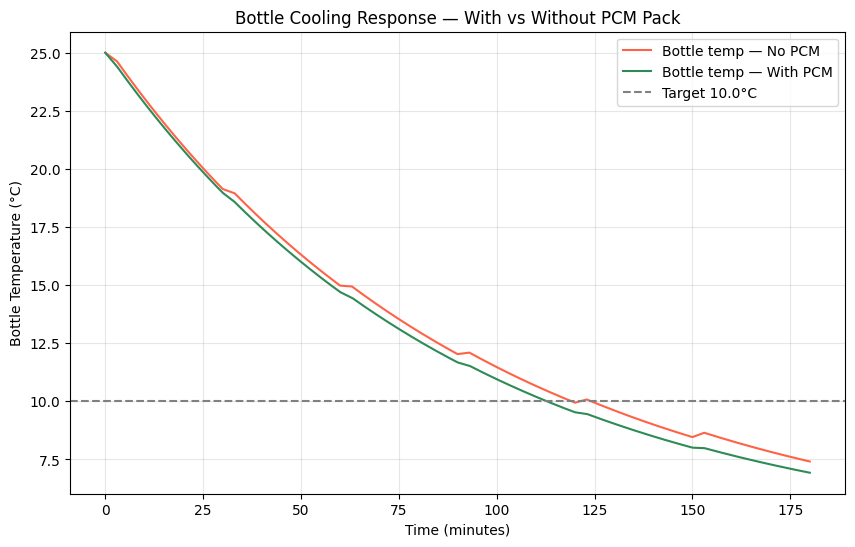

In [7]:
# CELL 7 — Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(time/60, T_bottle_no_pcm, label="Bottle temp — No PCM", color="tomato")
plt.plot(time/60, T_bottle_with_pcm, label="Bottle temp — With PCM", color="seagreen")
plt.axhline(target_temp, linestyle="--", color="gray", label=f"Target {target_temp}°C")
plt.xlabel("Time (minutes)")
plt.ylabel("Bottle Temperature (°C)")
plt.title("Bottle Cooling Response — With vs Without PCM Pack")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What this chart tells us:** the green curve (with PCM) reaches the 10°C target noticeably faster than the red curve (without PCM) — **112.8 minutes vs 119.2 minutes, a 5.3% faster cooling response**. The PCM pack is damping the cabin-temperature swings caused by door openings, so the bottle sees a steadier, slightly colder effective environment instead of repeatedly losing ground every time the door opens. A 5% response-time improvement sounds modest in isolation, but compounded across every door-opening event in a day, it's a real, measurable customer-facing benefit — "how fast does my drink actually get cold" — directly traceable to the same PCM patent as Day 15.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

# Pull the CURRENT notebook's content directly from Colab's frontend --
# works even though the .ipynb was never saved as a file on the VM disk
nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day16_pcm_integration.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 16 - PCM integration model", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 16 - PCM integration model", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")